In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

companies = [f'Company_{i}' for i in range(1, 101)]
industries = ['Retail', 'Manufacturing', 'Tech', 'Healthcare', 'Finance']

data = {
    'Company': companies,
    'Industry': np.random.choice(industries, 100),
    'Invoice_Amount': np.random.randint(5000, 150000, 100),
    'Days_Outstanding': np.random.randint(1, 180, 100),
}

df = pd.DataFrame(data)
df['Paid_Amount'] = (df['Invoice_Amount'] * np.random.uniform(0, 1, 100)).astype(int)
df['Outstanding_Balance'] = df['Invoice_Amount'] - df['Paid_Amount']

print(df.shape)
print(df.head(10))

(100, 6)
      Company       Industry  Invoice_Amount  Days_Outstanding  Paid_Amount  \
0   Company_1     Healthcare           27662               164        25306   
1   Company_2        Finance           13392               147         4957   
2   Company_3           Tech           35535                90          549   
3   Company_4        Finance          118569               147       110069   
4   Company_5        Finance           57256               148        24516   
5   Company_6  Manufacturing           94135                96        90996   
6   Company_7           Tech          132478                52       127658   
7   Company_8           Tech           40222               161        34309   
8   Company_9           Tech           82373               168        24254   
9  Company_10        Finance          128684               128        49555   

   Outstanding_Balance  
0                 2356  
1                 8435  
2                34986  
3                 850

In [2]:
# Aging Analysis — группировка по срокам долга
def aging_bucket(days):
    if days <= 30:
        return '0-30 days'
    elif days <= 60:
        return '31-60 days'
    elif days <= 90:
        return '61-90 days'
    else:
        return '90+ days'

df['Aging_Bucket'] = df['Days_Outstanding'].apply(aging_bucket)

# Сводка по aging
aging_summary = df.groupby('Aging_Bucket').agg(
    Companies=('Company', 'count'),
    Total_Outstanding=('Outstanding_Balance', 'sum'),
    Avg_Outstanding=('Outstanding_Balance', 'mean')
).reset_index()

print(aging_summary)

  Aging_Bucket  Companies  Total_Outstanding  Avg_Outstanding
0    0-30 days         14             637577     45541.214286
1   31-60 days         18             551327     30629.277778
2   61-90 days          8             312828     39103.500000
3     90+ days         60            2513717     41895.283333


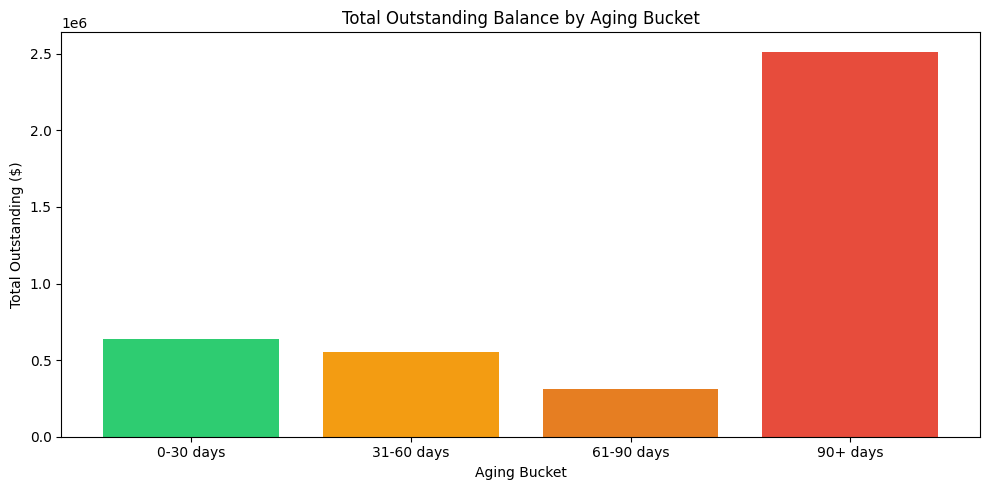

In [3]:
# График 1 — Outstanding Balance по Aging Bucket
order = ['0-30 days', '31-60 days', '61-90 days', '90+ days']
colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']

plt.figure(figsize=(10, 5))
bars = plt.bar(order, 
               [aging_summary[aging_summary['Aging_Bucket']==b]['Total_Outstanding'].values[0] for b in order],
               color=colors)
plt.title('Total Outstanding Balance by Aging Bucket')
plt.xlabel('Aging Bucket')
plt.ylabel('Total Outstanding ($)')
plt.tight_layout()
plt.show()

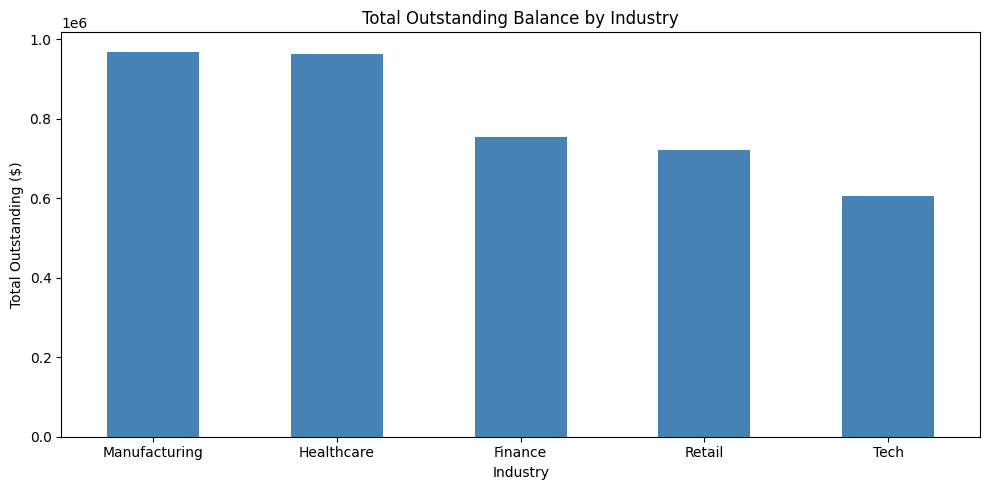

In [4]:
# График 2 — Outstanding по индустриям
plt.figure(figsize=(10, 5))
df.groupby('Industry')['Outstanding_Balance'].sum().sort_values(ascending=False).plot(kind='bar', color='steelblue')
plt.title('Total Outstanding Balance by Industry')
plt.xlabel('Industry')
plt.ylabel('Total Outstanding ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

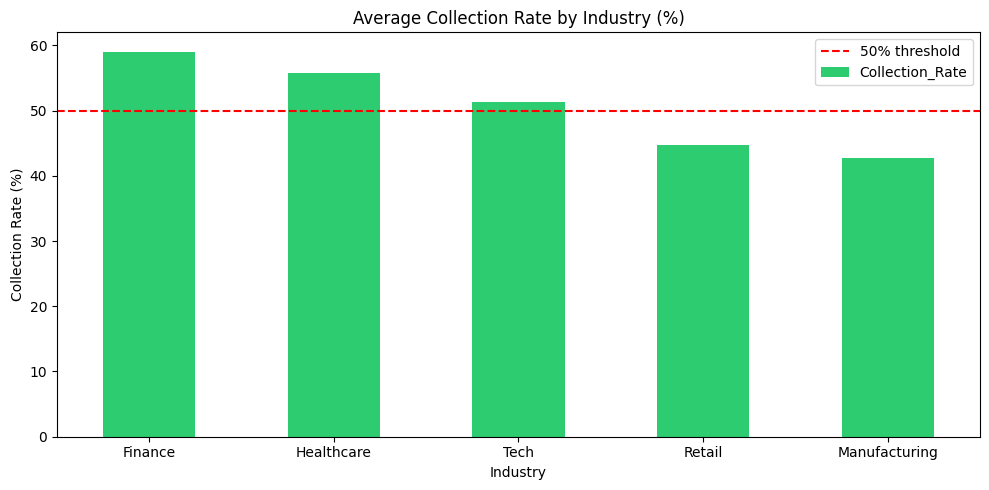

In [5]:
# График 3 — Collection Rate по индустриям
df['Collection_Rate'] = df['Paid_Amount'] / df['Invoice_Amount'] * 100

plt.figure(figsize=(10, 5))
df.groupby('Industry')['Collection_Rate'].mean().sort_values(ascending=False).plot(kind='bar', color='#2ecc71')
plt.title('Average Collection Rate by Industry (%)')
plt.xlabel('Industry')
plt.ylabel('Collection Rate (%)')
plt.xticks(rotation=0)
plt.axhline(y=50, color='red', linestyle='--', label='50% threshold')
plt.legend()
plt.tight_layout()
plt.show()

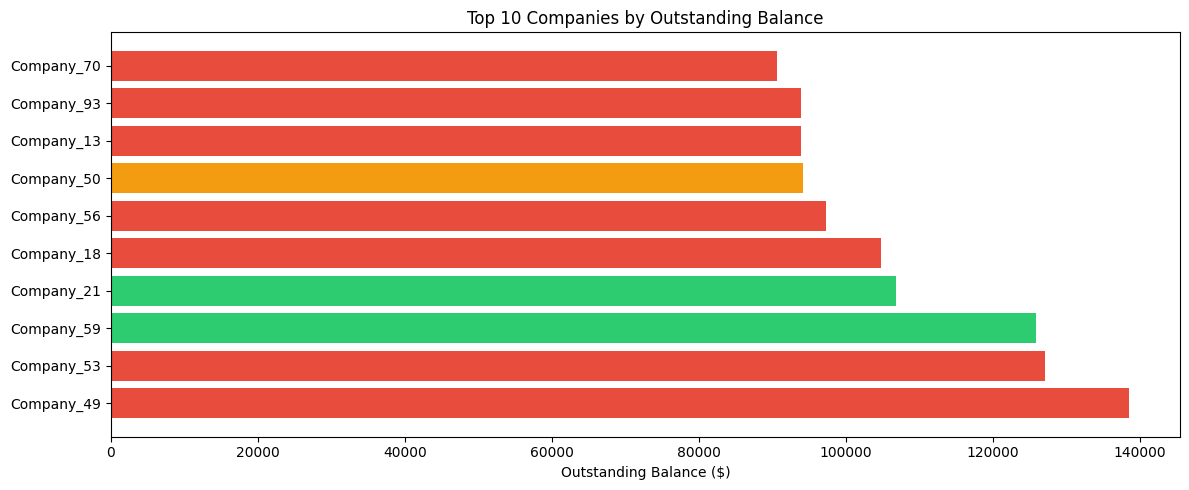

       Company  Outstanding_Balance  Days_Outstanding       Industry
48  Company_49               138492               104  Manufacturing
52  Company_53               127053               153     Healthcare
58  Company_59               125803                54     Healthcare
20  Company_21               106781                 7  Manufacturing
17  Company_18               104718               159        Finance
55  Company_56                97318               128         Retail
49  Company_50                94135                84     Healthcare
12  Company_13                93903               104        Finance
92  Company_93                93859               147           Tech
69  Company_70                90555               136     Healthcare


In [6]:
# График 4 — Топ 10 должников
top10 = df.nlargest(10, 'Outstanding_Balance')[['Company', 'Outstanding_Balance', 'Days_Outstanding', 'Industry']]

plt.figure(figsize=(12, 5))
colors = ['#e74c3c' if d > 90 else '#f39c12' if d > 60 else '#2ecc71' for d in top10['Days_Outstanding']]
plt.barh(top10['Company'], top10['Outstanding_Balance'], color=colors)
plt.title('Top 10 Companies by Outstanding Balance')
plt.xlabel('Outstanding Balance ($)')
plt.tight_layout()
plt.show()

print(top10)